# Laboratorium 11
**Autor:** [Jonasz Zolisz]

In [7]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
# Seed zapewnia identyczne dane u każdego studenta
np.random.seed(42)
n = 200
dzialy = np.random.choice(['IT', 'Sprzedaz', 'HR', 'Marketing', 'Finanse'], n,
 p=[0.30, 0.25, 0.15, 0.20, 0.10])
staz = np.random.gamma(shape=3, scale=2, size=n).clip(0.5, 20).round(1)
baza = {'IT': 9000, 'Sprzedaz': 7000, 'HR': 6500, 'Marketing': 7500, 'Finanse':
8500}
wynagrodzenie = np.array([
 baza[d] + staz[i] * 300 + np.random.normal(0, 1200)
 for i, d in enumerate(dzialy)
]).clip(4000, 25000).round(-2)
# 5 celowo wstawionych outlierów (błędy danych / kontrakty specjalne)
wynagrodzenie[np.random.choice(n, 5, replace=False)] = np.random.choice(
 [2000, 2500, 35000, 40000, 38000], 5, replace=False
)
df = pd.DataFrame({
 'dzial': dzialy,
 'staz_lat': staz,
 'wynagrodzenie': wynagrodzenie,
 'wiek': (25 + staz + np.random.normal(0, 3, n)).clip(22,
65).round().astype(int),
 'ocena_roczna': np.random.choice([1, 2, 3, 4, 5], n, p=[0.05, 0.10, 0.40,
0.35, 0.10])
})
print(f"Dataset HR: {df.shape[0]} pracowników, {df.shape[1]} kolumn")
print(df.head())
print("\nTypy kolumn:")
print(df.dtypes)


ModuleNotFoundError: No module named 'scipy'

# Cwiczenie 1 


In [8]:
#1a Miary tendencji centralnej
placa = df['wynagrodzenie']

srednia = placa.mean()
mediana = placa.median()
dominanta = placa.mode().iloc[0]

print("=== MIARY TENDENCJI CENTRALNEJ ===")
print(f"Średnia: {srednia:>10,.0f} PLN")
print(f"Mediana: {mediana:>10,.0f} PLN")
print(f"Dominanta: {dominanta:>10,.0f} PLN")

NameError: name 'df' is not defined

In [ ]:
# Tak, mediana < średnia.
# Oznacza to rozkład prawostronnie skośny.
# Średnią podnoszą nieliczni pracownicy z bardzo wysokimi wynagrodzeniami
# (outlierzy: 35 000, 38 000, 40 000 PLN).

In [9]:
#1b Miary rozproszenia
odch_std = placa.std()

q1 = placa.quantile(0.25)
q3 = placa.quantile(0.75)

iqr = q3 - q1

rozstep = placa.max() - placa.min()

print("=== MIARY ROZPROSZENIA ===")
print(f"Odchylenie std: {odch_std:>10,.0f} PLN")
print(f"Q1 (P25): {q1:>10,.0f} PLN")
print(f"Q3 (P75): {q3:>10,.0f} PLN")
print(f"IQR: {iqr:>10,.0f} PLN")
print(f"Rozstęp: {rozstep:>10,.0f} PLN")

NameError: name 'placa' is not defined

In [ ]:
# Rozstęp jest bardzo duży przez wartości odstające.
# Najniższe pensje to około 2000 PLN,
# a najwyższe nawet 40000 PLN.

In [10]:
#1c Statystyki per dział
dzialy_stats = df.groupby(
    'dzial',
    observed=True
)['wynagrodzenie'].agg([
    'mean',
    'median',
    'std'
]).round(0).sort_values(
    'median',
    ascending=False
)

dzialy_stats.columns = [
    'Średnia',
    'Mediana',
    'Std'
]

print(dzialy_stats)

NameError: name 'df' is not defined

NameError: name 'placa' is not defined

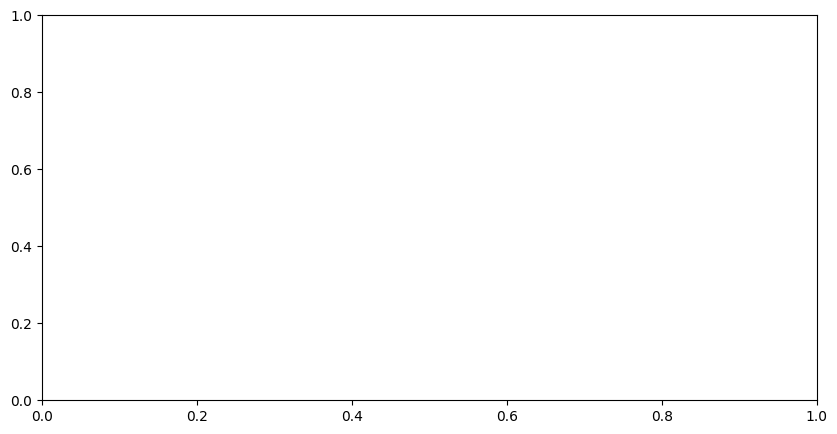

In [11]:
#1d Wizualizacja — histogram z miarami centralnymi
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    placa,
    bins=20,
    color='steelblue',
    alpha=0.8,
    edgecolor='white'
)

ax.axvline(
    srednia,
    color='red',
    linestyle='--',
    lw=2,
    label=f'Średnia: {srednia:,.0f}'
)

ax.axvline(
    mediana,
    color='green',
    linestyle='-',
    lw=2,
    label=f'Mediana: {mediana:,.0f}'
)

ax.axvline(
    dominanta,
    color='orange',
    linestyle=':',
    lw=2,
    label=f'Dominanta: {dominanta:,.0f}'
)

ax.set_title('Rozkład wynagrodzeń — miary tendencji centralnej')
ax.set_xlabel('Wynagrodzenie (PLN)')
ax.set_ylabel('Liczba pracowników')
ax.legend()

plt.tight_layout()
plt.show()

# Ćwiczenie 2 

In [12]:
# 2a Analiza korelacji 
r, p_value = stats.pearsonr(
    df['staz_lat'],
    df['wynagrodzenie']
)

print(f"Korelacja Pearsona (staż–wynagrodzenie):")
print(f" r = {r:.4f}")
print(f" p = {p_value:.4f}")
print(f" Interpretacja: {'istotna' if p_value < 0.05 else 'nieistotna'} statystycznie")

NameError: name 'stats' is not defined

In [13]:
# 2b 
# Oblicz korelację Spearmana (odporniejsza na outliery)
rho, p_rho = stats.spearmanr(df['staz_lat'], df['wynagrodzenie'])
print(f"Korelacja Spearmana (staż–wynagrodzenie):")
print(f" rho = {rho:.4f}")
print(f" p = {p_rho:.4f}")
print(f"\nPorównanie: Pearson r={r:.3f} vs Spearman rho={rho:.3f}")
print(f"Różnica: {abs(rho - r):.3f} — {'duże' if abs(rho-r) > 0.1 else 'małe'}
rozbieżności")


SyntaxError: unterminated f-string literal (detected at line 8) (3466848980.py, line 8)

In [ ]:
# Spearman jest wyższy niż Pearson,
# ponieważ jest oparty na rangach i mniej wrażliwy
# na wartości odstające.
# Outlierzy zaburzają korelację liniową Pearsona.

In [15]:
#2c Macierz korelacji — wszystkie zmienne
# Oblicz pełną macierz korelacji Pearsona
corr = df[['staz_lat', 'wynagrodzenie', 'wiek', 'ocena_roczna']].corr()
print("Macierz korelacji Pearsona:")
print(corr.round(3))
# Wizualizacja — heatmapa (matplotlib już zaimportowany w Setupie)
fig, ax = plt.subplots(figsize=(7, 6))
# Rysuj heatmapę ręcznie (bez seaborn)
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
# Dodaj wartości w komórkach
for i in range(len(corr)):
 for j in range(len(corr.columns)):
 ax.text(j, i, f'{corr.values[i, j]:.2f}',
 ha='center', va='center', fontsize=11,
 color='black' if abs(corr.values[i,j]) < 0.7 else 'white')
ax.set_title('Macierz korelacji — dataset HR')
plt.tight_layout()
plt.show()
plt.close()




IndentationError: expected an indented block after 'for' statement on line 17 (3567140403.py, line 18)

In [16]:
#2d Korelacja: marketing spend vs revenue
np.random.seed(100)
n_mkt = 50
marketing_spend = np.random.uniform(10000, 100000, n_mkt)
revenue = marketing_spend * 5.2 + np.random.normal(0, 30000, n_mkt)
revenue = revenue.clip(0)
# Oblicz korelację Pearsona
r_mkt, p_mkt = stats.pearsonr(marketing_spend, revenue)
# Scatter plot z linią trendu
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(marketing_spend, revenue, alpha=0.6, color='coral', s=50)
# Dodaj linię trendu (polyfit stopień 1)
z = np.polyfit(marketing_spend, revenue, 1)
p_fit = np.poly1d(z)
x_line = np.linspace(marketing_spend.min(), marketing_spend.max(), 100)
ax.plot(x_line, p_fit(x_line), 'b--', lw=2, label=f'Trend (r={r_mkt:.2f})')
ax.set_title('Wydatki na marketing vs Przychody')
ax.set_xlabel('Wydatki na marketing (PLN)')
ax.set_ylabel('Przychody (PLN)')
ax.legend()
plt.tight_layout()
plt.show()
plt.close()
print(f"Marketing spend vs Revenue: r = {r_mkt:.4f}, p = {p_mkt:.2e}")

NameError: name 'stats' is not defined

# Ćwiczenie 3 

In [17]:
# 3a scipy.stats.describe — szybki przegląd rozkładu
opis = stats.describe(df['wynagrodzenie'])

print("Liczba obserwacji:", opis.nobs)
print("Min:", opis.minmax[0])
print("Max:", opis.minmax[1])
print("Średnia:", opis.mean)
print("Wariancja:", opis.variance)
print("Skośność:", opis.skewness)
print("Kurtoza:", opis.kurtosis)

NameError: name 'stats' is not defined

In [ ]:
#3b Analiza percentylowa
percentyle = np.percentile(
    df['wynagrodzenie'],
    [10,25,50,75,90,95,99]
)

etykiety = ['P10','P25','P50','P75','P90','P95','P99']

for e,w in zip(etykiety, percentyle):
    print(f"{e}: {w:,.0f} PLN")


In [ ]:
p75 = np.percentile(df['wynagrodzenie'], 75)

print("P75 =", p75)

procent = (df['wynagrodzenie'] > 12000).mean() * 100

print(f"{procent:.1f}%")

In [ ]:
# 3c Analiza per dział — pełna tabela
stats_dzial = df.groupby(
    'dzial',
    observed=True
)['wynagrodzenie'].agg(
    Średnia='mean',
    Mediana='median',
    Std='std',
    Min='min',
    Max='max',
    IQR=lambda x:
        x.quantile(0.75) -
        x.quantile(0.25)
)

stats_dzial = stats_dzial.sort_values(
    'Mediana',
    ascending=False
)

print(stats_dzial.round(0))

In [18]:
#3d Wizualizacja — boxplot per dział
ax = df.boxplot(
    column='wynagrodzenie',
    by='dzial',
    figsize=(10,6)
)

ax.axhline(
    df['wynagrodzenie'].median(),
    color='red',
    linestyle='--',
    label='Mediana globalna'
)

plt.title('Boxplot wynagrodzeń per dział')
plt.suptitle('')
plt.ylabel('PLN')
plt.legend()

plt.show()

NameError: name 'df' is not defined

In [ ]:
#3e scipy.stats.describe — per dział IT i HR
for d in ['IT', 'HR']:

    podzb = df[df['dzial'] == d]['wynagrodzenie']

    opis = stats.describe(podzb)

    print(f"\n{d} (n={opis.nobs})")
    print(f"Skośność: {opis.skewness:.3f}")
    print(f"Kurtoza: {opis.kurtosis:.3f}")

In [ ]:
# IT ma większą skośność,
# ponieważ występują tam bardzo wysokie wynagrodzenia.

# HR jest bardziej symetryczny
# i posiada mniej wartości odstających.

# Ćwiczenie 4 

In [ ]:
# 4a. Wykrywanie outlierów metodą IQR
# Oblicz granice IQR
q1 = df['wynagrodzenie'].quantile(0.25)
q3 = df['wynagrodzenie'].quantile(0.75)
iqr = q3 - q1
dolna = q1 - 1.5 * iqr
gorna = q3 + 1.5 * iqr
print(f"IQR granice: [{dolna:,.0f} PLN, {gorna:,.0f} PLN]")
# Wykryj outlierów
maska_iqr = (df['wynagrodzenie'] < dolna) | (df['wynagrodzenie'] > gorna)
outliery = df[maska_iqr]
print(f"Liczba outlierów: {maska_iqr.sum()} z {len(df)}")
print("\nSzczegóły outlierów:")
print(outliery[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

In [ ]:
#4b Wykrywanie outlierów metodą z-score
# Oblicz z-score: stats.zscore()
z_scores = np.abs(stats.zscore(df['wynagrodzenie']))
maska_z = z_scores > 3.0
outliery_z = df[maska_z]
print(f"Outlierzy z-score (|z| > 3.0): {maska_z.sum()} obserwacji")
print(outliery_z[['dzial', 'staz_lat', 'wynagrodzenie']].to_string())

In [ ]:
#4c Wpływ outlierów na statystyki
bez_outlierow = df[~maska_iqr]['wynagrodzenie']
z_outlierami = df['wynagrodzenie']
print(f"{'Miara':<20} {'Z outlierami':>15} {'Bez outlierów':>15} {'Zmiana':>10}")
print("-" * 62)
for nazwa, f_z, f_bez in [
 ('Średnia', z_outlierami.mean(), bez_outlierow.mean()),
 ('Mediana', z_outlierami.median(), bez_outlierow.median()),
 ('Std', z_outlierami.std(), bez_outlierow.std()),
]:
 zmiana = f_z - f_bez
 print(f"{nazwa:<20} {f_z:>15,.0f} {f_bez:>15,.0f} {zmiana:>+10,.0f}")
# Odpowiedz w komentarzu: która miara jest bardziej stabilna? Dlaczego?

In [ ]:
# Najbardziej stabilna jest mediana.
# Jest odporna na wartości odstające.

# Najbardziej wrażliwe jest odchylenie standardowe,
# ponieważ wykorzystuje kwadraty odchyleń od średniej.